# Imports:

In [30]:
import numpy as np
import pandas as pd
import seaborn as sns
from tqdm import trange
import matplotlib.pyplot as plt
import statsmodels.api as sm
from scipy.special import expit

import sys
sys.path.append("../../Utils/")
from data_generating_utils import generate_population_data

import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

## Hyperparams:

In [31]:
population_size = 100_000
true_betas = [1, -1]
sample_size = 1_000
num_iter = 1_000

pop_index = 1
iter_val = 0
rand_generator = np.random.default_rng(seed=333 * pop_index + iter_val)

In [32]:
make_greyscale = True

In [33]:
if make_greyscale:
    high_contrast_greys = ['#000000', '#808080', '#C0C0C0']
    sns.set_palette(high_contrast_greys)
    savefile_suffix = '_greyscale'
else:
    sns.set_palette('deep')
    savefile_suffix = ''

# Run:

100%|████████████████████████████████████████████████████████████████████████████████████| 2/2 [00:43<00:00, 21.51s/it]


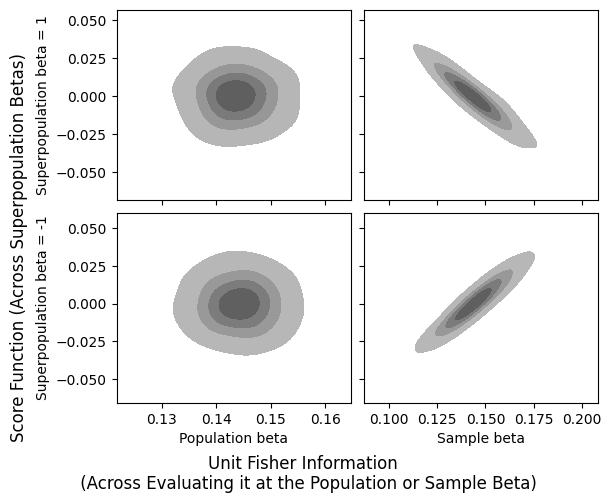

In [34]:
fig, axes = plt.subplots(
    len(true_betas), 2, constrained_layout=True, figsize=(6, 5), sharex='col', sharey='row'
)

for true_beta_index in trange(len(true_betas)):
    true_beta = true_betas[true_beta_index]
    pop_data = generate_population_data(
        population_size,
        rand_generator,
        true_beta=true_beta,
    )
    pop_model = sm.Logit(endog=pop_data["y"], exog=pop_data["x_0"]).fit(disp=0)
    pop_beta = pop_model.params[0]

    pop_data["pop_eta"] = expit(pop_beta * pop_data["x_0"])
    pop_data["pop_score"] = pop_data.eval("x_0 * (y - pop_eta)")
    pop_data["pop_neg_deriv_score"] = pop_data.eval(
        "(x_0 ** 2) * (1 - pop_eta) * pop_eta"
    )

    """
        Plot score vs FI evaluated at the Population:
    """
    ax = axes[true_beta_index][0]
    all_sample_data_for_score = []
    for _ in range(num_iter):
        all_sample_data_for_score.append(
            pop_data.sample(sample_size)[["pop_score", "pop_neg_deriv_score"]].mean()
        )

    all_sample_data_for_score = pd.concat(all_sample_data_for_score, axis=1).T
    sns.kdeplot(
        data=all_sample_data_for_score,
        x="pop_neg_deriv_score",
        y="pop_score",
        fill=True,
        bw_adjust=1.8,
        levels=5,
        ax=ax,
    )

    ax.set_ylabel(f"Superpopulation beta = {true_beta}")
    if true_beta_index == len(true_betas) - 1:
        ax.set_xlabel("Population beta")
    else:
        ax.set_xlabel("")

    """
        Plot score vs FI evaluated at the Sample Beta:
    """
    ax = axes[true_beta_index][1]
    all_sample_data_for_score = []
    for _ in range(num_iter):
        samp_data = pop_data.sample(sample_size).copy()
        samp_model = sm.Logit(endog=samp_data["y"], exog=samp_data["x_0"]).fit(disp=0)
        samp_beta = samp_model.params[0]
        samp_data["eta_sample"] = expit(samp_beta * samp_data["x_0"])
        samp_data["neg_deriv_score_sample"] = samp_data.eval(
            "(x_0 ** 2) * (1 - eta_sample) * eta_sample"
        )
        all_sample_data_for_score.append(
            samp_data[
                ["pop_score", "pop_neg_deriv_score", "neg_deriv_score_sample"]
            ].mean()
        )

    all_sample_data_for_score = pd.concat(all_sample_data_for_score, axis=1).T

    sns.kdeplot(
        data=all_sample_data_for_score,
        x="neg_deriv_score_sample",
        y="pop_score",
        fill=True,
        bw_adjust=1.8,
        levels=5,
        ax=ax,
    )

    ax.set_ylabel("")
    if true_beta_index == len(true_betas) - 1:
        ax.set_xlabel("Sample beta")
    else:
        ax.set_xlabel("")

# fig.suptitle(
#     "Score Function vs Unit Fisher Information Across \n"
#     + "Superpopulation Betas and Fisher Information Evaluation Points"
# )
fig.suptitle(
    ""
)
fig.supylabel("Score Function (Across Superpopulation Betas)")
fig.supxlabel(
    "Unit Fisher Information \n (Across Evaluating it at the "
    + "Population or Sample Beta)"
)

plt.savefig(f"score_vs_unit_fi{savefile_suffix}.png")